In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

## Section 3.1

In [2]:
nu = np.array([[-1, -1, 1, 0],[1, 1, -1, 0],[0,1,-1,1]]) # stochiometric vectors

def aCalc(c, x):
    a1 = c[0]*(x[0]*x[1])*(x[0]>=1 and x[1]>=1)
    a2 = c[1]*(x[2])*(x[2]>=1)
    a3 = c[2]*(x[2])*(x[2]>=1)
    return np.array([a1, a2, a3])

### 3.1.1
Verify that if aj kept constant, then pj are independent and poisson distributed with lambda = aj*tau

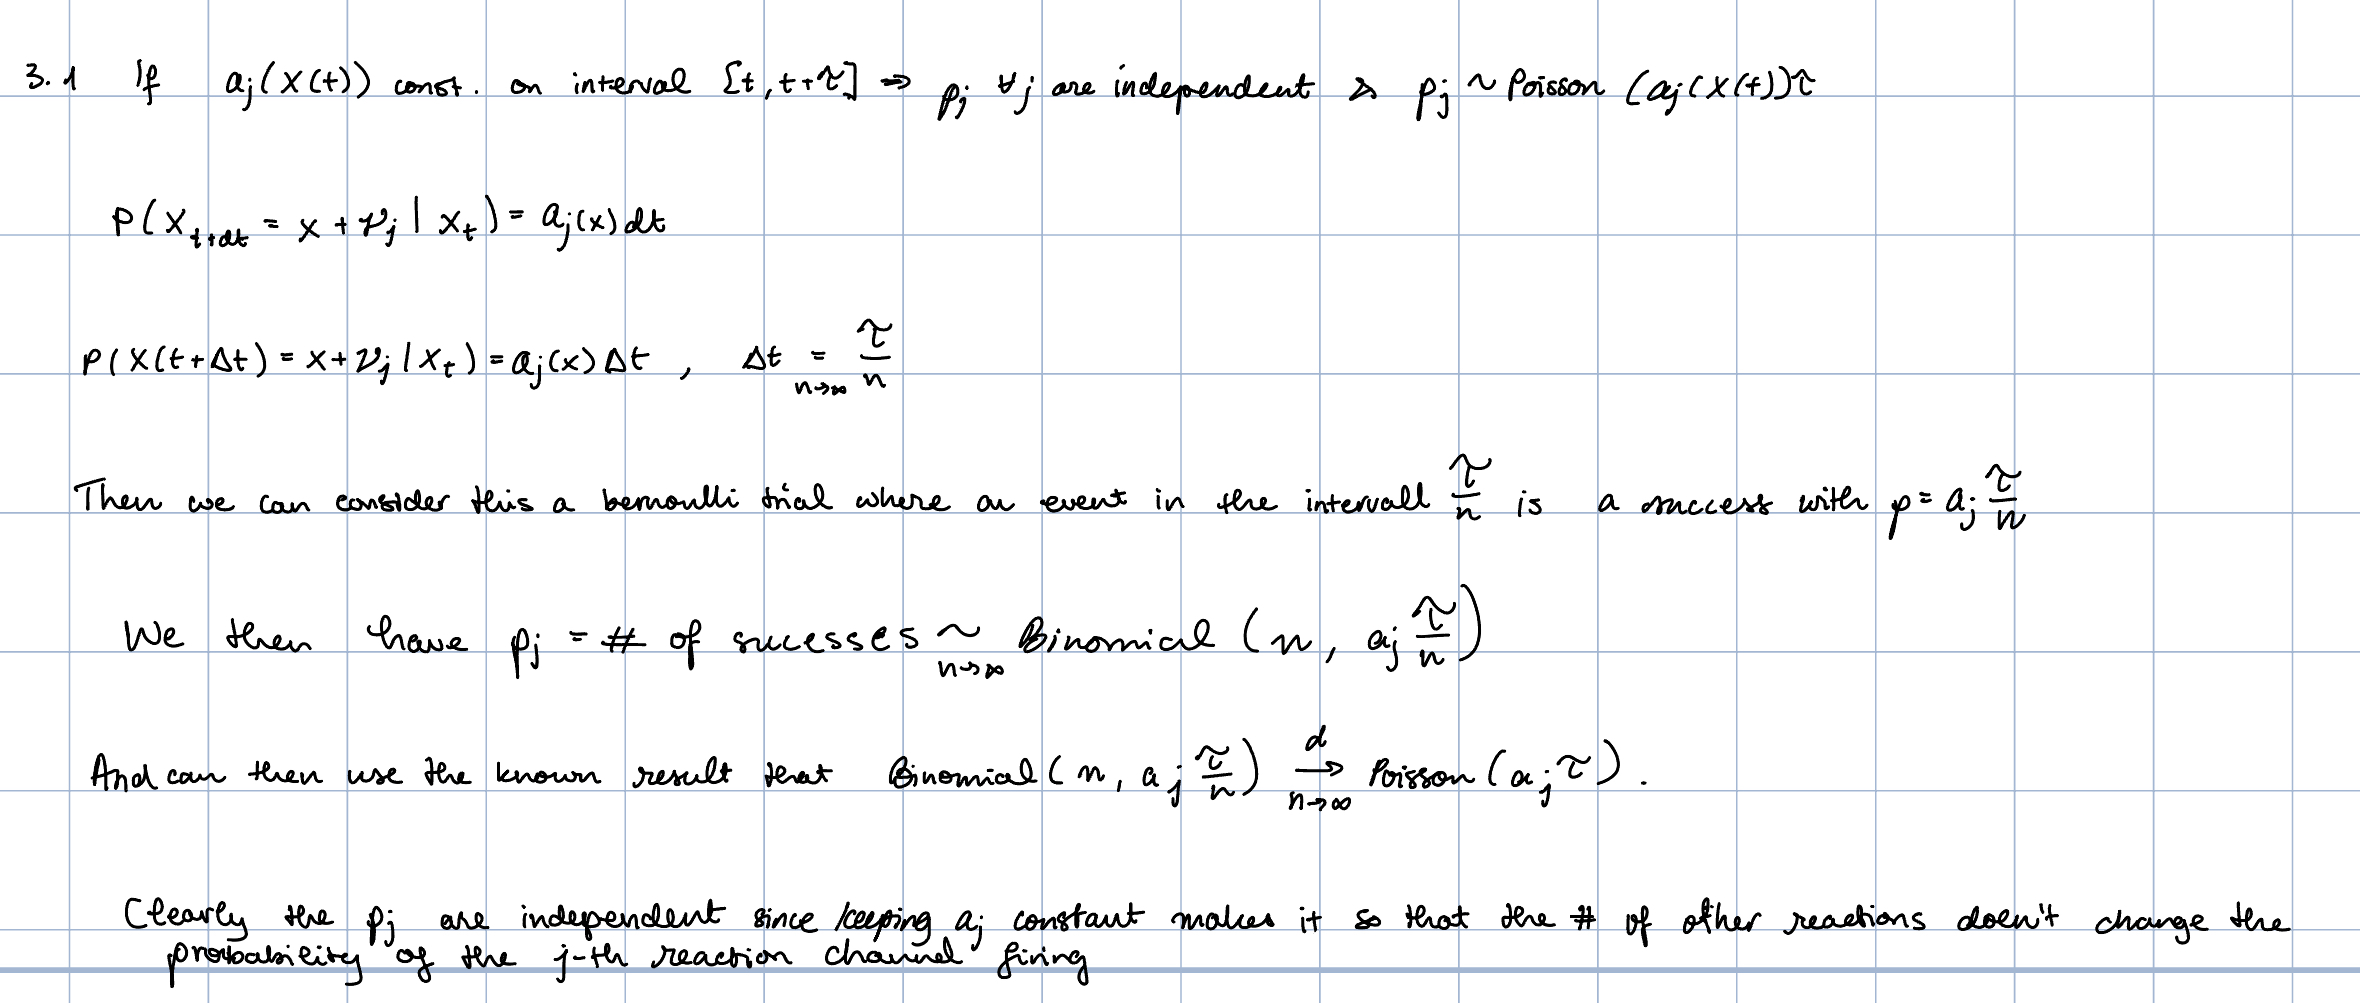

### 3.1.2

Implementing tau-leaping algorithm and using the same rate constants as in section 2.1 with T=50 and tau=0.2

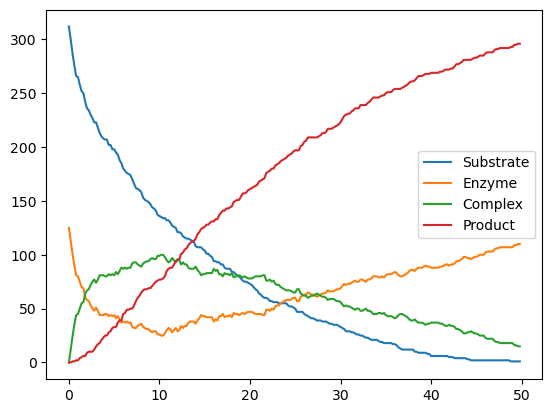

In [4]:
def explicit_tau_leaping(c, X0, T, tau):
    t = np.arange(0, T, tau)
    X = np.zeros((len(t),4))

    X[0]=X0

    for i in range(0, len(t)-1):
        a = aCalc(c, X[i])
        #aSum = sum(a)
        
        P = np.random.poisson(lam = (a*tau)) # (3,) array of pj values
        X[i+1] = X[i] + P @ nu
    return t, X


c = [0.0017, 1e-4, 0.1] # rate constants

T = 50 # Total time
tau = 0.2

X0 = [312, 125, 0, 0] # Initial # of each species

t, X = explicit_tau_leaping(c, X0, T, tau)
X = np.transpose(X)
n = len(t)-1
plt.plot(t, X[0], label="Substrate")
plt.plot(t, X[1], label="Enzyme")
plt.plot(t, X[2], label="Complex")
plt.plot(t, X[3], label="Product")
plt.legend()
plt.show()

### 3.1.3
Estimating Zdelt = E[X4(T)], compare with Z obtained in 2.3. Fix a threshold 1 - alpha and iteratively increase N until you achieve the desired tolerance. Compare at that threshold the confidence interval obtained by SSA algorithm with explicit tau leaping.

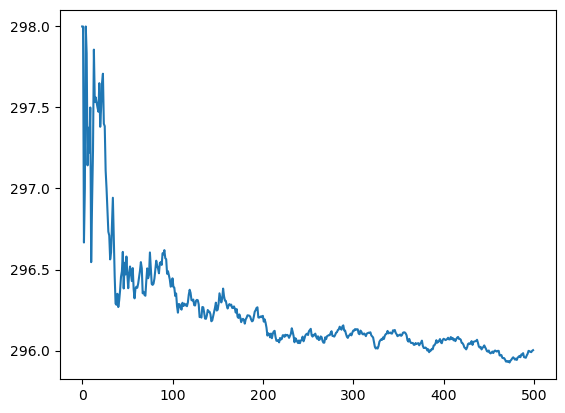

In [ ]:
'''
Test plot to estimate a good Nb
'''

Nb = 500
X4 = np.zeros(Nb)
muNs= [0]

for i in range(Nb):
    t, X = implicit_tau_leaping(c, X0, T, tau)
    X4[i] = X[-1,3]
    muNs.append((i/(i+1))*muNs[-1] + 1/(i+1) * X[-1,3])
    
plt.plot(range(0, Nb), muNs[1:])

In [ ]:
Nb = 150
X4 = np.zeros(Nb)
muNs= [0]
for i in range(Nb):
    t, X = explicit_tau_leaping(c, X0, T, tau)
    X4[i] = X[-1,3]
    muNs.append((i/(i+1))*muNs[-1] + 1/(i+1) * X[-1,3])
    
alpha = 0.05  # for 95% confidence
cAlph = stats.norm.ppf(1 - alpha/2)
tol = 0.5

muNb = 1/Nb * sum(X4)
sigNb = np.sqrt(1/(Nb-1) * sum((X4 - muNb)**2))

N, muN, sigN = Nb, muNb, sigNb

while (sigN * cAlph/np.sqrt(N) > tol):
    
    N = N+1
    
    t, X = explicit_tau_leaping(c, X0, T, tau)
    
    muN = (N/(N+1))*muN + 1/(N+1) * X[-1,3]
    sigN = np.sqrt((N-1)/N * sigN**2 + 1/(N+1) * (X[-1,3] - muN)**2)

In [12]:
print("95% confidence interval for mu: [", muN-(sigN * cAlph/np.sqrt(N)),' , ',muN+(sigN * cAlph/np.sqrt(N)),']')
print(f'halfwidth is {sigN * cAlph/np.sqrt(N)}')
print("Calculated by N = ", N, " iterations")

95% confidence interval for mu: [ 296.6250816340018  ,  297.6234344950305 ]
halfwidth is 0.4991764305143626
Calculated by N =  309  iterations


Test for values of tau >= 0.2 and different sample sizes.

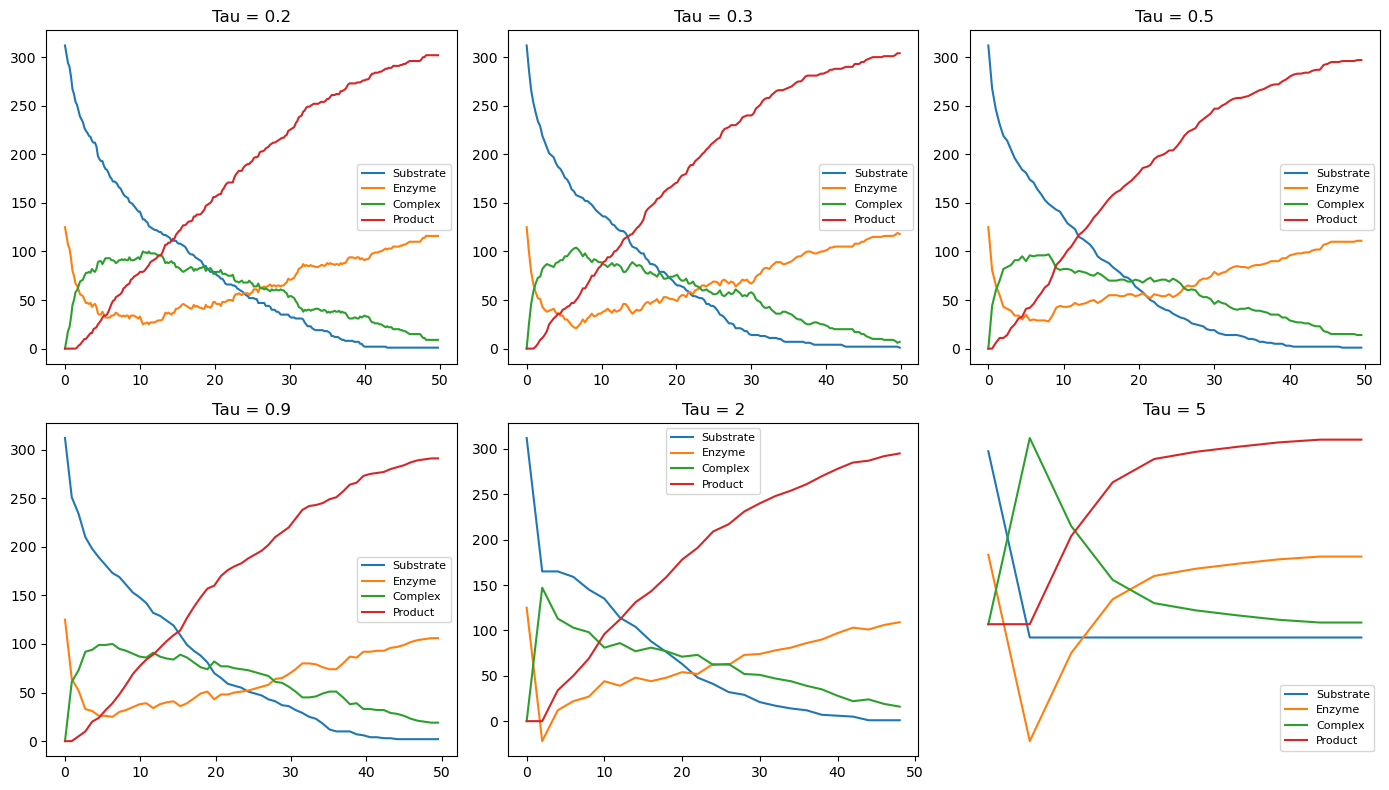

In [ ]:
tauTest = [0.2, 0.3, 0.5, 0.9, 2, 5]

'''
Parameters
'''
c = [0.0017, 1e-4, 0.1] # rate constants
T = 50 # Total time
X0 = [312, 125, 0, 0] # Initial # of each species


# Create 2x3 grid (6 subplots, last one unused)
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=False)
axes = axes.flatten()

for i, tau in enumerate(tauTest):
    t, X = explicit_tau_leaping(c, X0, T, tau)
    X = np.transpose(X)

    ax = axes[i]
    ax.plot(t, X[0], label="Substrate")
    ax.plot(t, X[1], label="Enzyme")
    ax.plot(t, X[2], label="Complex")
    ax.plot(t, X[3], label="Product")

    ax.set_title(f"Tau = {tau}")
    ax.legend(fontsize=8)

# Hide unused subplot
axes[-1].axis("off")

fig.tight_layout()
plt.show()


In [ ]:
'''
Parameters
'''
c = [0.0017, 1e-4, 0.1] # rate constants
T = 50 # Total time
X0 = [312, 125, 0, 0] # Initial # of each species

def pilot_run(Nb):
    
    X4 = np.zeros(Nb)

    for i in range(Nb):
        t, X = explicit_tau_leaping(c, X0, T, tau)
        X4[i] = X[-1,3]

    muN = 1/Nb * sum(X4)
    sigN = np.sqrt(1/(Nb-1) * sum((X4 - muN)**2))
    
    return muN, sigN

def iterative_update(alpha, tol, Nb, Nmax):

    cAlph = stats.norm.ppf(1-alpha/2)
    N = Nb

    muN, sigN = pilot_run(Nb)

    while (sigN * cAlph/np.sqrt(N) > tol and N<Nmax):
    
        N = N+1
        
        t, X = explicit_tau_leaping(c, X0, T, tau)
        
        muN = (N/(N+1))*muN + 1/(N+1) * X[-1,3]
        sigN = np.sqrt((N-1)/N * sigN**2 + 1/(N+1) * (X[-1,3] - muN)**2)
    
    halfwidth  = sigN * cAlph/np.sqrt(N)

    return muN, halfwidth, N

tauTest = [0.2, 0.3, 0.5, 0.9, 2, 5]
Nb = 150
alpha = 0.05 
tol = 0.3
Nmax = 2000

results = np.zeros((len(tauTest), 3))

for i, tau in enumerate(tauTest):
    results[i]=iterative_update(alpha, tol, Nb, Nmax)



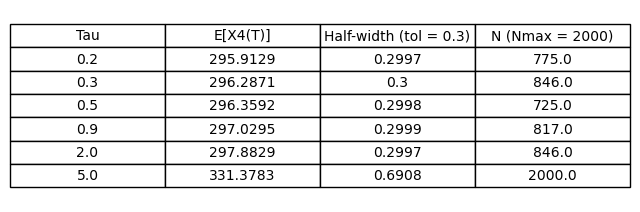

In [24]:
muNs, halwidths, Ns = results[:,0], results[:,1], results[:,2]


# Combine into a single table array (converted to strings for nice display)
table_data = np.column_stack([tauTest, muNs, halwidths, Ns])

# Column labels
col_labels = ["Tau", "E[X4(T)]", f"Half-width (tol = {tol})", f"N (Nmax = {Nmax})"]

fig, ax = plt.subplots(figsize=(8, 2.5))
ax.axis('off')  # Hide plot frame

table = ax.table(
    cellText=np.round(table_data, 4),  # Rounded for readability
    colLabels=col_labels,
    loc='center',
    cellLoc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.4)  # stretch table

plt.show()

In [28]:
def MC_specificSampleSize(N, alpha):

    cAlph = stats.norm.ppf(1-alpha/2)
    X4 = np.zeros(N)

    for i in range(N):
        t, X = explicit_tau_leaping(c, X0, T, tau)
        X4[i] = X[-1,3]

    muN = 1/N * sum(X4)
    sigN = np.sqrt(1/(N-1) * sum((X4 - muN)**2))
    
    halfwidth  = sigN * cAlph/np.sqrt(N)

    return muN, halfwidth

In [36]:
tauTest = [0.2, 0.3, 0.5, 0.9, 1.7, 3.3, 6.5]
Ns = [300, 800, 1500]
alpha = 0.05 

results = np.zeros((len(tauTest), len(Ns), 2))

for i, tau in enumerate(tauTest):
    for j, N in enumerate(Ns):
        results[i, j]=MC_specificSampleSize(N, alpha)

IndexError: index 6 is out of bounds for axis 0 with size 6

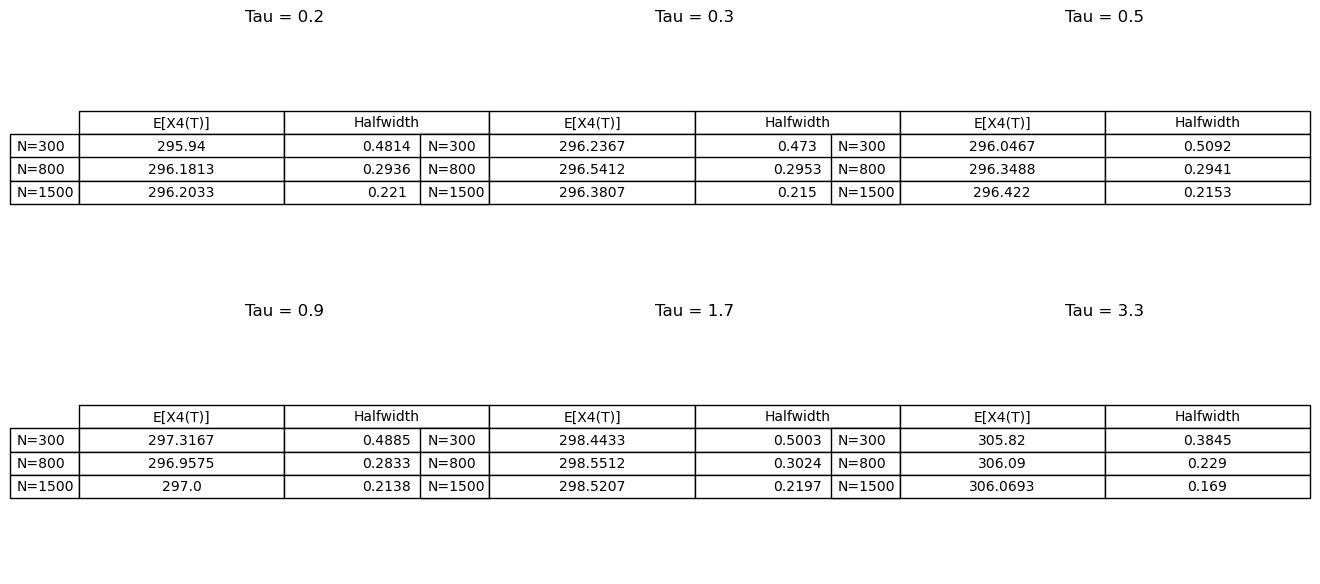

In [37]:
# ---- Plot tables ----

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes = axes.flatten()

for i, tau in enumerate(tauTest):

    ax = axes[i]
    ax.axis("off")

    # Table data: results[i] is shape (3, 2)
    table_data = np.round(results[i], 4)

    col_labels = ["E[X4(T)]", "Halfwidth"]
    row_labels = [f"N={N}" for N in Ns]

    table = ax.table(
        cellText=table_data,
        rowLabels=row_labels,
        colLabels=col_labels,
        loc="center",
        cellLoc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.4)

    ax.set_title(f"Tau = {tau}", pad=10)

# Empty last cell if needed
if len(tauTest) < len(axes):
    for k in range(len(tauTest), len(axes)):
        axes[k].axis("off")

fig.tight_layout()
plt.show()


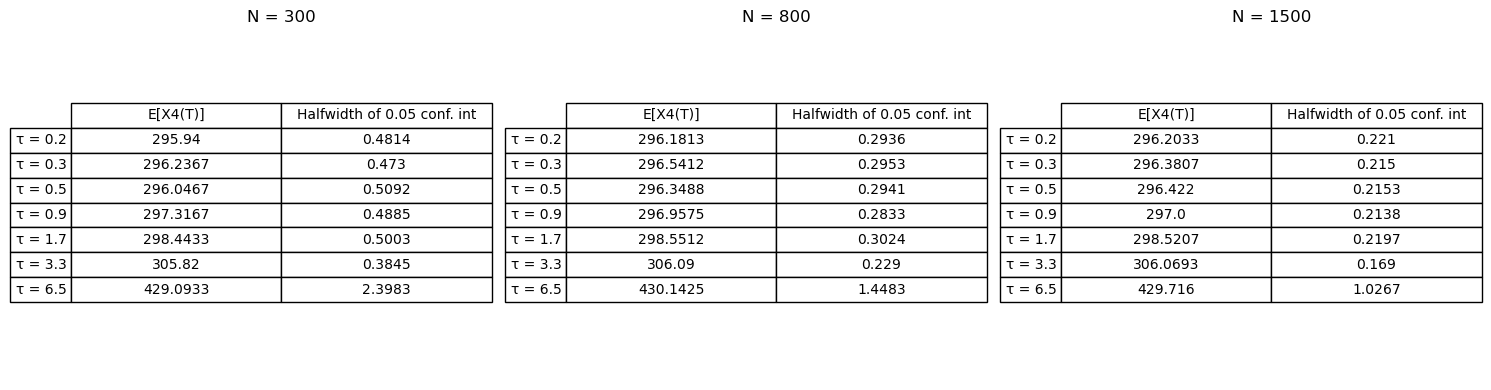

In [38]:
# ---- Plot tables: one table per N ----

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes = axes.flatten()

for j, N in enumerate(Ns):

    ax = axes[j]
    ax.axis("off")

    # table_data shape is (len(tauTest), 2) for this N
    table_data = np.round(results[:, j, :], 4)

    col_labels = ["E[X4(T)]", "Halfwidth of 0.05 conf. int"]
    row_labels = [f"τ = {tau}" for tau in tauTest]

    table = ax.table(
        cellText=table_data,
        rowLabels=row_labels,
        colLabels=col_labels,
        loc="center",
        cellLoc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.3)

    ax.set_title(f"N = {N}", pad=2)

fig.tight_layout()
plt.show()

### 3.1.4

Implicit tau-leaping algorithm

a)

y = X(t) + tau * sum ( aj(y) * nu)
f(y) = y - X(t) - tau * sum ( aj(y) * nu) = 0

y(k+1) = y(k) - inv(jacobi)*f(y(k))

b)

Sampling Pj from poisson(aj(y)*tau)

In [6]:
nu = np.array([[-1,1,0],
                [-1,1,1],
                [1,-1,-1],
                [0,0,1]])

# propensities, now without indicators for the sake of continuity, so that newton's method converges consistently
def aCalc(c, x):
    a1 = c[0]*(x[0]*x[1])
    a2 = c[1]*(x[2])
    a3 = c[2]*(x[2])
    return np.array([a1, a2, a3])

Estimate Z = E[X4(T)], iteratively increase N, test for different tau and sample size.

In [ ]:
# Jacobi, found on paper
J = lambda y: np.array([[1+tau*c[0]*y[1],     tau*c[0]*y[0],        -tau*c[1],               0],
                        [tau*c[0]*y[1],       1 + tau*c[0]*y[0],    -tau*(c[1]+c[2]),        0],
                        [-tau*c[0]*y[1],      -tau*c[0]*y[0],       1 + tau*(c[1]+c[2]),     0],
                        [0,                   0,                    -tau*c[2],               1]])

f = lambda y, a, x: y - x - tau*(nu @ a)

def newtons(X, tol):
    # Initial calculations of y0 and y1
    y = X.copy()
    a = aCalc(c, y)
    F = tau* (nu@a)

    while (np.linalg.norm(F)>tol): # Checking for convergence

        J = np.array([  [1+tau*c[0]*y[1],     tau*c[0]*y[0],        -tau*c[1],               0],
                        [tau*c[0]*y[1],       1 + tau*c[0]*y[0],    -tau*(c[1]+c[2]),        0],
                        [-tau*c[0]*y[1],      -tau*c[0]*y[0],       1 + tau*(c[1]+c[2]),     0],
                        [0,                   0,                    -tau*c[2],               1]])
        
        delY = np.linalg.solve(J, -F)
        y += delY

        a = aCalc(c, y)
        F = (y - X - tau*(nu @ a))
        
    return y

def implicit_tau_leaping(c, X0, T, tau, tol=1e-4):
    t = np.arange(0, T, tau)
    X = np.zeros((len(t),4))

    X[0]=X0

    for i in range(0, len(t)-1):
        
        y = newtons(X[i], tol)
        a = np.maximum (aCalc(c, y), 0) # Since we removed the indicators from aCalc for convergence of newton's, we reintroduce the requirement here
        P = np.random.poisson(lam = (a*tau)) # (3,) array of pj values drawn from aj(y)*tau
        X[i+1] = X[i] + nu @ P
    return t, X


In [9]:
Nb = 150
X4 = np.zeros(Nb)
muNs= [0]
for i in range(Nb):
    t, X = implicit_tau_leaping(c, X0, T, tau, 1e-4)
    X4[i] = X[-1,3]
    muNs.append((i/(i+1))*muNs[-1] + 1/(i+1) * X[-1,3])
    
alpha = 0.05  # for 95% confidence
cAlph = stats.norm.ppf(1 - alpha/2)
tolN = 0.2

muNb = 1/Nb * sum(X4)
sigNb = np.sqrt(1/(Nb-1) * sum((X4 - muNb)**2))

N, muN, sigN = Nb, muNb, sigNb

while (sigN * cAlph/np.sqrt(N) > tolN):
    
    N = N+1
    
    t, X = implicit_tau_leaping(c, X0, T, tau, 1e-4)
    
    muN = (N/(N+1))*muN + 1/(N+1) * X[-1,3]
    sigN = np.sqrt((N-1)/N * sigN**2 + 1/(N+1) * (X[-1,3] - muN)**2)

In [10]:
print("95% confidence interval for mu: [", muN-(sigN * cAlph/np.sqrt(N)),' , ',muN+(sigN * cAlph/np.sqrt(N)),']')
print(f'halfwidth is {sigN * cAlph/np.sqrt(N)}')
print("Calculated by N = ", N, " iterations")

95% confidence interval for mu: [ 294.9127982886553  ,  295.31279754700125 ]
halfwidth is 0.199999629172991
Calculated by N =  1792  iterations


In [17]:
def update_J(J, y, c, tau):
    y0, y1 = y[0], y[1]
    c0, c1, c2 = c

    J[0,0] = 1 + tau*c0*y1
    J[0,1] = tau*c0*y0

    J[1,0] = tau*c0*y1
    J[1,1] = 1 + tau*c0*y0

    J[2,0] = -tau*c0*y1
    J[2,1] = -tau*c0*y0

    J[0,2] = -tau*c1
    J[1,2] = -tau*(c1+c2)
    J[2,2] = 1 + tau*(c1+c2)
    J[3,2] = -tau*c2

    # entries that are constant
    J[0,3] = J[1,3] = J[2,3] = 0
    J[3,0] = J[3,1] = 0
    J[3,3] = 1


In [ ]:
def newtons(X, tol, c, tau, nu):
    y = X.copy()
    a = aCalc(c, y)
    F = y - X - tau*(nu @ a)

    J = np.empty((4,4))   # allocated once

    while np.linalg.norm(F) > tol:
        update_J(J, y, c, tau)

        delY = np.linalg.solve(J, -F)
        y += delY

        a = aCalc(c, y)
        F = y - X - tau*(nu @ a)

    return y


In [ ]:
def implicit_tau_leaping(c, X0, T, tau, tol, nu):
    t = np.arange(0, T, tau)
    X = np.zeros((len(t), 4))
    X[0] = X0

    for i in range(len(t)-1):
        y = newtons(X[i], tol, c, tau, nu)
        a = np.maximum(aCalc(c, y), 0)
        P = np.random.poisson(a * tau)
        X[i+1] = X[i] + nu @ P

    return t, X


In [ ]:
Nb = 150
X4 = np.zeros(Nb)
muNs= [0]
for i in range(Nb):
    t, X = implicit_tau_leaping(c, X0, T, tau, 1e-4, nu)
    X4[i] = X[-1,3]
    muNs.append((i/(i+1))*muNs[-1] + 1/(i+1) * X[-1,3])
    
alpha = 0.05  # for 95% confidence
cAlph = stats.norm.ppf(1 - alpha/2)
tolN = 0.2

muNb = 1/Nb * sum(X4)
sigNb = np.sqrt(1/(Nb-1) * sum((X4 - muNb)**2))

N, muN, sigN = Nb, muNb, sigNb

while (sigN * cAlph/np.sqrt(N) > tolN):
    
    N = N+1
    
    t, X = implicit_tau_leaping(c, X0, T, tau, 1e-4, nu)
    
    muN = (N/(N+1))*muN + 1/(N+1) * X[-1,3]
    sigN = np.sqrt((N-1)/N * sigN**2 + 1/(N+1) * (X[-1,3] - muN)**2)

In [23]:
print("95% confidence interval for mu: [", muN-(sigN * cAlph/np.sqrt(N)),' , ',muN+(sigN * cAlph/np.sqrt(N)),']')
print(f'halfwidth is {sigN * cAlph/np.sqrt(N)}')
print("Calculated by N = ", N, " iterations")

95% confidence interval for mu: [ 295.0921456632985  ,  295.49208622075747 ]
halfwidth is 0.1999702787295093
Calculated by N =  1609  iterations


In [ ]:
def pilot_run(Nb):
    
    X4 = np.zeros(Nb)

    for i in range(Nb):
        t, X = implicit_tau_leaping(c, X0, T, tau)
        X4[i] = X[-1,3]

    muN = 1/Nb * sum(X4)
    sigN = np.sqrt(1/(Nb-1) * sum((X4 - muN)**2))
    
    return muN, sigN

def iterative_update(alpha, tol, Nb, Nmax):

    cAlph = stats.norm.ppf(1-alpha/2)
    N = Nb

    muN, sigN = pilot_run(Nb)

    while (sigN * cAlph/np.sqrt(N) > tol and N<Nmax):
    
        N = N+1
        
        t, X = explicit_tau_leaping(c, X0, T, tau)
        
        muN = (N/(N+1))*muN + 1/(N+1) * X[-1,3]
        sigN = np.sqrt((N-1)/N * sigN**2 + 1/(N+1) * (X[-1,3] - muN)**2)
    
    halfwidth  = sigN * cAlph/np.sqrt(N)

    return muN, halfwidth, N




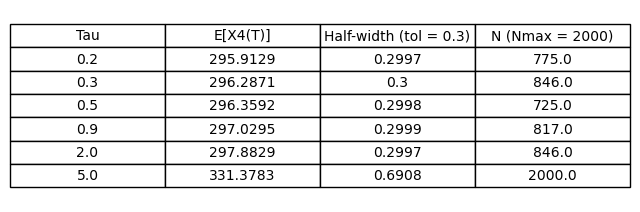

In [ ]:
muNs, halwidths, Ns = results[:,0], results[:,1], results[:,2]


# Combine into a single table array (converted to strings for nice display)
table_data = np.column_stack([tauTest, muNs, halwidths, Ns])

# Column labels
col_labels = ["Tau", "E[X4(T)]", f"Half-width (tol = {tol})", f"N (Nmax = {Nmax})"]

fig, ax = plt.subplots(figsize=(8, 2.5))
ax.axis('off')  # Hide plot frame

table = ax.table(
    cellText=np.round(table_data, 4),  # Rounded for readability
    colLabels=col_labels,
    loc='center',
    cellLoc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.4)  # stretch table

plt.show()